In [ ]:
! pip install spicy

In [ ]:
import numpy as np
from spicy import stats
from matplotlib import pyplot as plt
import seaborn as sns

### 1. DEFINICIÓN DE HIPÓTESIS
#### H0 (Nula): Ambos dados son iguales.
#### H1 (Alternativa): El dado B esta trucado con respecto el Dado A.

In [ ]:
print("--- CONFIGURACIÓN DEL EXPERIMENTO ---")
# 1. El valor teórico de un dado normal (sacar un 6) es 1/6 ≈ 0.1666
prob_teorica = 1/6
prob_normal = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
prob_trucado = [0.14, 0.14, 0.14, 0.14, 0.14, 0.30]
alpha = 0.05 # Nivel de significancia
caras = [1, 2, 3, 4, 5, 6] # Caras del dado
print(f"La probabilidad de sacar un número en concreto en un lanzamiento de un dado es de: {prob_teorica}\n")
print(f"Nivel de significancia (alpha): {alpha}\n")

--- CONFIGURACIÓN DEL EXPERIMENTO ---
La probabilidad de sacar un número en concreto en un lanzamiento de un dado es de: 0.16666666666666666

Nivel de significancia (alpha): 0.05



In [ ]:
# Lanzamos nuestros dados 1000 veces
# Simulamos que este dado saca un 6 el 30% de las veces (¡está muy trucado!)
np.random.seed(42)
lanzamientos_normal = np.random.choice(caras, size=1000, p=prob_normal)
lanzamientos_trucado = np.random.choice(caras, size=1000, p=prob_trucado)

exitos_observados_h0 = (lanzamientos_normal == 6).sum()
exitos_observados_h1 = (lanzamientos_trucado == 6).sum()

print(f"Resultados: Sacamos un '6' {exitos_observados_h0} veces de 1000 lanzamientos.")
print(f"Resultados: Sacamos un '6' {exitos_observados_h1} veces de 1000 lanzamientos.")

Resultados: Sacamos un '6' 164 veces de 1000 lanzamientos.
Resultados: Sacamos un '6' 307 veces de 1000 lanzamientos.


In [ ]:
# Test binomial
resultado_h0 = stats.binomtest(exitos_observados_h0, 1000, prob_teorica)
resultado_h1 = stats.binomtest(exitos_observados_h1, 1000, prob_teorica)
print(f"Resultado H0: {resultado_h0}")
print(f"Resultado H1: {resultado_h1}")

Resultado H0: BinomTestResult(k=164, n=1000, alternative='two-sided', statistic=0.164, pvalue=0.8652296183875705)
Resultado H1: BinomTestResult(k=307, n=1000, alternative='two-sided', statistic=0.307, pvalue=6.940415518611489e-28)


In [ ]:
if resultado_h0.pvalue < alpha:
    print("Para el Dado A: Rechazamos la hipótesis nula")
else:
    print("Para el Dado A: No rechazamos la hipótesis nula")

if resultado_h1.pvalue < alpha:
    print("Para el Dado B: Rechazamos la hipótesis nula")
else:
    print("Para el Dado B: No rechazamos la hipótesis nula")

Para el Dado A: No rechazamos la hipótesis nula
Para el Dado B: Rechazamos la hipótesis nula


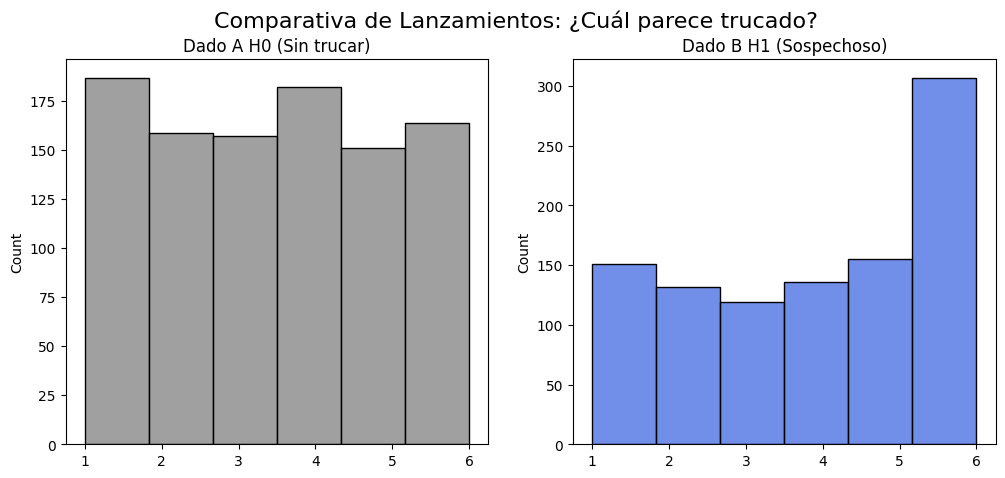

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Título principal para todo el gráfico
fig.suptitle("Comparativa de Lanzamientos: ¿Cuál parece trucado?", fontsize=16)

# Gráfico para H0 (Dado Normal)
sns.histplot(lanzamientos_normal, ax=axes[0], color="gray", bins=6)
axes[0].set_title("Dado A H0 (Sin trucar)")
axes[0].set_xticks([1, 2, 3, 4, 5, 6])
axes[0].set_xticklabels(['1', '2', '3', '4', '5', '6'])

# Gráfico para H1 (Dado Sospechoso)
sns.histplot(lanzamientos_trucado, ax=axes[1], color="royalblue", bins=6)
axes[1].set_title("Dado B H1 (Trucado)")
axes[0].set_xticks([1, 2, 3, 4, 5, 6])
axes[0].set_xticklabels(['1', '2', '3', '4', '5', '6'])

plt.show()